In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
base_folder = "/content/drive/MyDrive/Colab Notebooks/airline_passenger_satisfaction"
%cd "{base_folder}"

/content/drive/MyDrive/Colab Notebooks/airline_passenger_satisfaction


In [3]:
!pip install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.7/398.7 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.3 MB/s eta 0:00:00


   Unnamed: 0      id  Gender      Customer Type  Age   Type of Travel  \
0           0   70172    Male     Loyal Customer   13  Personal Travel   
1           1    5047    Male  disloyal Customer   25  Business travel   
2           2  110028  Female     Loyal Customer   26  Business travel   
3           3   24026  Female     Loyal Customer   25  Business travel   
4           4  119299    Male     Loyal Customer   61  Business travel   

      Class  Flight Distance  Inflight wifi service  \
0  Eco Plus              460                      3   
1  Business              235                      3   
2  Business             1142                      2   
3  Business              562                      2   
4  Business              214                      3   

   Departure/Arrival time convenient  ...  Inflight entertainment  \
0                                  4  ...                       5   
1                                  2  ...                       1   
2                

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 25/25 [00:03<00:00,  6.85it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

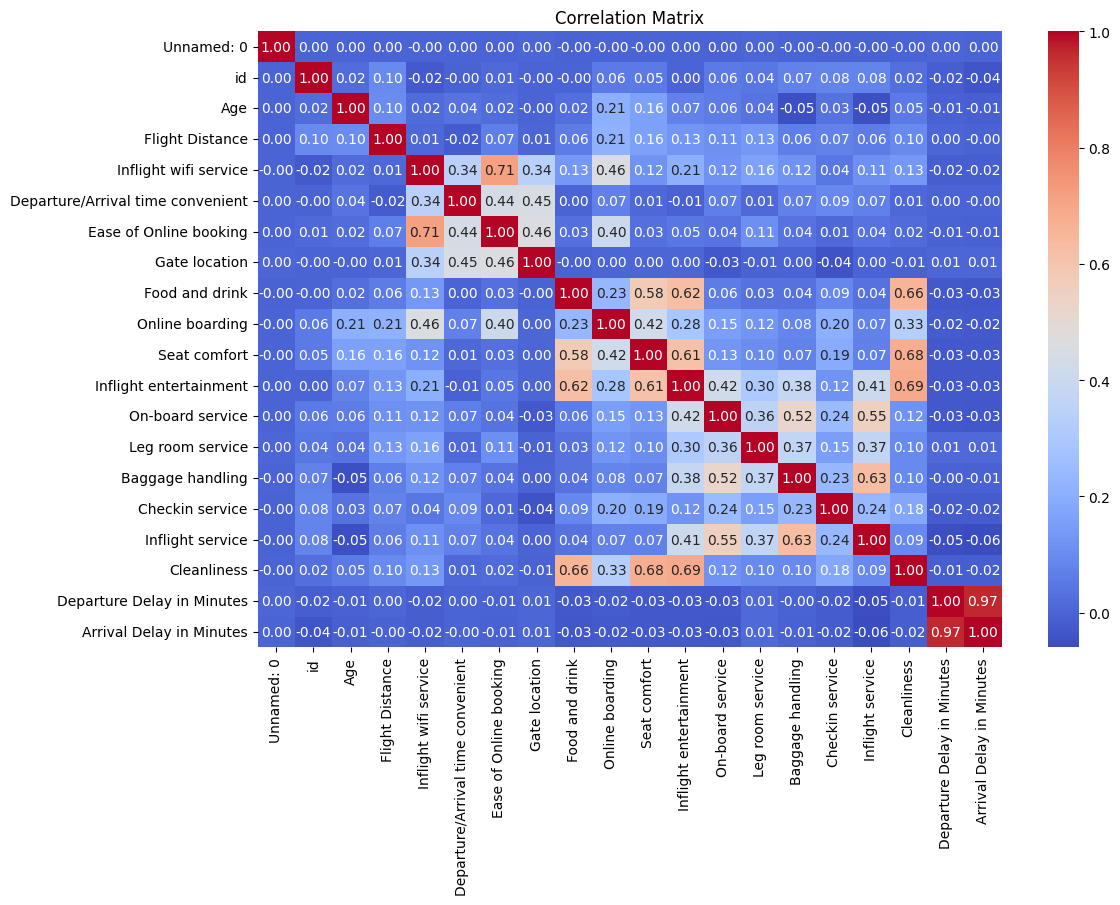


Data Cleanup Summary:
                              Feature     Type Missing Values  Outliers  \
0                          Unnamed: 0    int64      0 (0.00%)       0.0   
1                                  id    int64      0 (0.00%)       0.0   
2                              Gender   object      0 (0.00%)       NaN   
3                       Customer Type   object      0 (0.00%)       NaN   
4                                 Age    int64      0 (0.00%)       0.0   
5                      Type of Travel   object      0 (0.00%)       NaN   
6                               Class   object      0 (0.00%)       NaN   
7                     Flight Distance    int64      0 (0.00%)    2855.0   
8               Inflight wifi service    int64      0 (0.00%)       0.0   
9   Departure/Arrival time convenient    int64      0 (0.00%)       0.0   
10             Ease of Online booking    int64      0 (0.00%)       0.0   
11                      Gate location    int64      0 (0.00%)       0.0   
12

In [4]:
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
import ydata_profiling
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import os
import sqlite3
import pandas as pd

# Load the dataset
BASE_DIR = Path("data")
train_path = BASE_DIR / "train.csv"
test_path = BASE_DIR / "test.csv"
if not train_path.exists() or not test_path.exists():
  raise FileNotFoundError("train.csv or test.csv not found in data/")
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
df = pd.concat([train, test], ignore_index=True)

# Preview the data
print(df.head())
print(df.info())
print(df.describe(include='all'))

# Determine if stratification is needed
print("\nTarget value counts:")
print(df['satisfaction'].value_counts())

print("The target is imbalanced; stratification is recommended.")

# Profile the dataset
profile = ydata_profiling.ProfileReport(df, title="Airline Dataset Profiling Report", explorative=True)
profile.to_file("airline_data_profile.html")  # Outputs an HTML report

# Correlation matrix for numeric features
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_cols.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Automatic data-cleanup summary
cleanup_summary = []

for col in df.columns:
    col_data = df[col]
    missing_count = col_data.isnull().sum()
    missing_pct = missing_count / len(df) * 100

    if col_data.dtype in ['int64', 'float64']:
        # Detect capped/outlier values using IQR
        Q1 = col_data.quantile(0.25)
        Q3 = col_data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5*IQR
        upper_bound = Q3 + 1.5*IQR
        outliers = col_data[(col_data < lower_bound) | (col_data > upper_bound)].count()
        cleanup_summary.append({
            "Feature": col,
            "Type": col_data.dtype,
            "Missing Values": f"{missing_count} ({missing_pct:.2f}%)",
            "Outliers": outliers
        })
    else:
        # Categorical: check unique values
        unique_values = col_data.nunique()
        cleanup_summary.append({
            "Feature": col,
            "Type": col_data.dtype,
            "Missing Values": f"{missing_count} ({missing_pct:.2f}%)",
            "Unique Values": unique_values
        })

cleanup_df = pd.DataFrame(cleanup_summary)
print("\nData Cleanup Summary:")
print(cleanup_df)